# BrushCue Example: Spring Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/spring_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/spring-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Metal — adapter 'Apple M5' (IntegratedGpu), driver ''


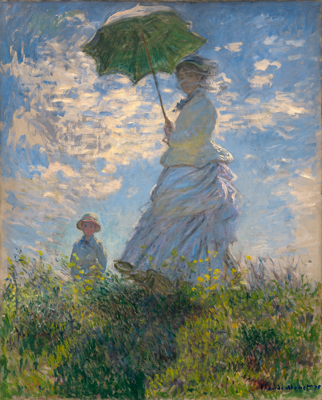

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
base_grade = input_image.l_curve(
    bc.Curve.pivoted_sigmoid(0.54, 0.94)
).saturation_adjust(1.04)
graded = base_grade.color_transformer_shader(
    "let shadow_weight = smoothstep(0.46, 0.12, input.r);\nlet highlight_weight = smoothstep(0.56, 0.9, input.r);\nlet a = input.g - 0.025 * shadow_weight + 0.018 * highlight_weight;\nlet b = input.b + 0.022 * highlight_weight - 0.008 * shadow_weight;\nreturn vec4f(input.r, a, b, input.a);",
    "",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create(),
)
bounds = input_image.bounds()
filtered = graded.bloom(0.7, 22.0, 0.07).crop(bounds)
strength = 1.0
graph = (
    filtered.opacity_scales(strength)
    .blend_alpha(input_image, bc.Transform2.identity())
    .crop(bounds)
)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
